## Script for producing ICESat-2 vs. ECCO V4r5 freeboard compariso)
- $\textbf{Figure S2}$: (a) Difference between ICESat-2 and (derived) ECCO V4r5 monthly mean freeboard.

In [1]:
import matplotlib.pyplot as plt
import pickle

In [3]:
with open('freeboard_data_sfig2a/is2_fb_monthly.pkl', 'rb') as f:
    is2_monthly = pickle.load(f)
with open('freeboard_data_sfig2a/ecco_fb_monthly.pkl', 'rb') as f:
    ecco_monthly = pickle.load(f)

In [4]:
# filter for only is2 dates
ecco_monthly = ecco_monthly[ecco_monthly['Date'] >= '2018-10-01']

ecco_anomaly = ecco_monthly['Mean_Freeboard'].values - is2_monthly['Mean_Freeboard'].values

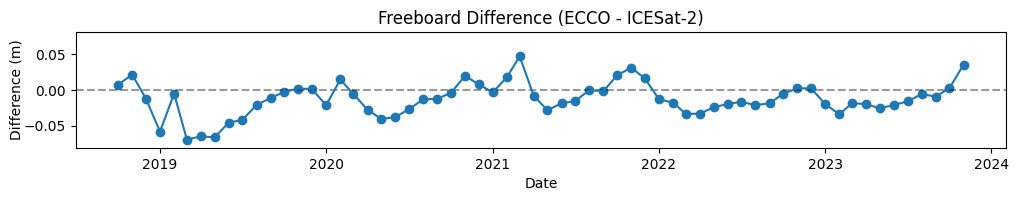

In [5]:
fig, ax = plt.subplots(figsize=(12,1.5))
plt.axhline(0, color='black', alpha=0.4, linestyle='--')
plt.scatter(ecco_monthly['Date'], ecco_anomaly);
plt.plot(ecco_monthly['Date'], ecco_anomaly);
plt.ylim(-0.081, 0.081)
plt.ylabel('Difference (m)', labelpad = -0.1);
plt.xlabel('Date');
plt.title('Freeboard Difference (ECCO - ICESat-2)');

fig.savefig('manuscript_figs/IS2_V4r5_freeboard_anomaly.png', bbox_inches='tight')

In [9]:
# Freeboard in ECCO (saved in ecco_fb_monthly.pkl) is calculated with the 
# the function below, using ECCO V4r5 fields:
# SIheff ("heff"; effective sea ice thickness), 
# SIhsnow ("hsnow"; snow depth), 
# and SIarea ("area"; sea ice area) fields.

def freeboard(area, hsnow, heff):
    SEAICE_rhoSnow = 3.300000000000000E+02
    SEAICE_rhoIce = 9.100000000000000E+02
    rhoConst = 1.029000000000000E+03
    recip_rhoConst = 1. / rhoConst

    SEAICE_area_reg = 2.000000000000000E-02
    area_reg_sq = SEAICE_area_reg * SEAICE_area_reg

    tmprecip_area = 1. / np.sqrt(area * area + area_reg_sq)
    tmphsnowact = hsnow * tmprecip_area
    tmpheffact = heff * tmprecip_area

    freeboard = (tmphsnowact + tmpheffact) - (tmphsnowact * SEAICE_rhoSnow + tmpheffact * SEAICE_rhoIce) * recip_rhoConst
    return freeboard